# Libraries and palettes

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import shutil
from pypalettes import load_cmap
from pypalettes import get_hex
import networkx as nx

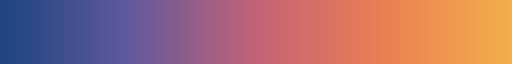

In [2]:
sunset2 = load_cmap('Sunset2', cmap_type='continuous')
sunset2

# Comprobations of RN Generation

mean: 1.702315638
std: 0    0.897682
dtype: float64
Theoretical mean: 1.7110914332847293
Theoretical std: 0.8944271909999159


c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\_core\fromnumeric.py:4062: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


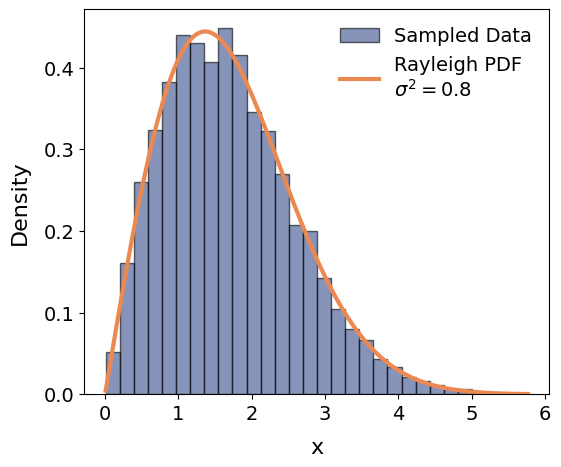

In [12]:
rayleigh_sample = pd.read_csv('test_rayleigh.txt', header = None)
print("mean:", np.mean(rayleigh_sample))
print("std:", np.std(rayleigh_sample))

# mean = 1.0;
# sigma = mean * np.sqrt(2.0 / np.pi);
variance = 0.8;
sigma = np.sqrt(variance*2/(4-np.pi))
mean = sigma * np.sqrt(np.pi / 2.0)
print('Theoretical mean:', mean)
print('Theoretical std:', np.sqrt((4 - np.pi) / 2.0 * sigma**2))
the_x = np.arange(np.min(rayleigh_sample), np.max(rayleigh_sample), 0.01)
the_y = (the_x / (sigma**2)) * np.exp(- (the_x**2) / (2.0 * sigma**2))

plt.figure(figsize=(6,5))
plt.hist(rayleigh_sample, bins=30, density=True, alpha=0.6, color=sunset2(0.1), edgecolor='black', label='Sampled Data')
plt.plot(the_x, the_y, color=sunset2(0.8), linewidth=3, label='Rayleigh PDF\n' r'$\sigma^2 = 0.8$')
plt.xlabel('x', fontsize = 16, labelpad = 10)
plt.ylabel('Density', fontsize = 16, labelpad = 10)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)
plt.legend(fontsize = 14, loc = 'best', frameon = False)


mean: 0.2953173248
std: 0    0.201887
dtype: float64


c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\_core\fromnumeric.py:4062: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


(-1.2, 1.2)

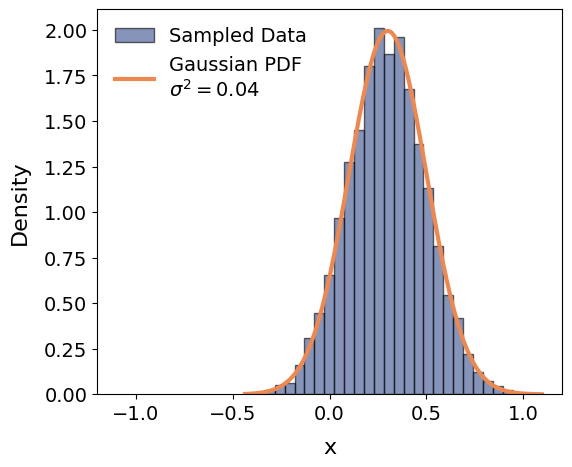

In [13]:
gaussian_sample = pd.read_csv('test_gaussian.txt', header = None)
print("mean:", np.mean(gaussian_sample))
print("std:", np.std(gaussian_sample))

mean = 0.3;
sigma = np.sqrt(0.04);
the_x = np.arange(np.min(gaussian_sample), np.max(gaussian_sample), 0.01)
the_y = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(- ((the_x - mean)**2) / (2.0 * sigma**2))

plt.figure(figsize=(6,5))
plt.hist(gaussian_sample, bins=30, density=True, alpha=0.6, color=sunset2(0.1), edgecolor='black', label='Sampled Data')
plt.plot(the_x, the_y, color=sunset2(0.8), linewidth=3, label='Gaussian PDF\n' r'$\sigma^2 = 0.04$')
plt.xlabel('x', fontsize = 16, labelpad = 10)
plt.ylabel('Density', fontsize = 16, labelpad = 10)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)
plt.legend(fontsize = 14, loc = 'best', frameon = False)
plt.xlim(-1.2, 1.2)


# Neuronal network

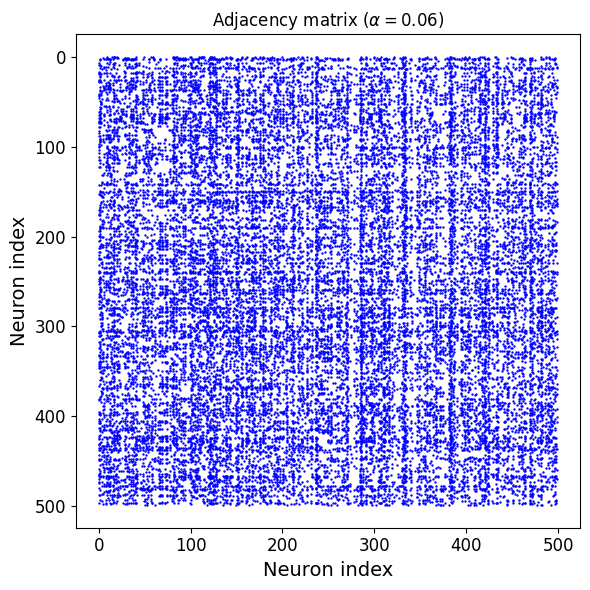

In [14]:
import numpy as np
import matplotlib.pyplot as plt

N = 500
file_adjacency_matrix = 'networks/adjacency_matrix_a0.0600.txt'

with open(file_adjacency_matrix, 'r') as f:
    lines = [line.strip() for line in f if line.strip()]

A = np.frombuffer("".join(lines).encode("ascii"), dtype=np.uint8) - ord('0')
A = A.reshape(N, N)
rows, cols = np.where(A == 1)
plt.figure(figsize=(6, 6))
plt.scatter(cols, rows, s=0.5, color='blue')
plt.gca().invert_yaxis()
plt.xlabel('Neuron index', fontsize=14)
plt.ylabel('Neuron index', fontsize=14)
plt.title(r'Adjacency matrix ($\alpha=0.06$)')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()


In [15]:
import numpy as np
import matplotlib.pyplot as plt
import os

import numpy as np

def read_adj_01txt(path, N=500):
    with open(path, "r") as f:
        lines = [line.strip() for line in f if line.strip()]
    if len(lines) != N:
        raise ValueError(f"{path}: {len(lines)} líneas, esperado {N}")
    # convierte caracteres '0'/'1' a uint8
    A = np.frombuffer(("".join(lines)).encode("ascii"), dtype=np.uint8) - ord('0')
    return A.reshape(N, N)

alpha = np.arange(0, 0.99, 0.0010)
filenames = [f'networks/adjacency_matrix_a{a:.4f}.txt' for a in alpha]
filenames = [f for f in filenames if os.path.exists(f)]
degrees = []
stds = []

for file in filenames:
    A = read_adj_01txt(file, N=500)
    np.fill_diagonal(A, 0)
    deg = A.sum(axis=1)
    degrees.append(deg.mean())
    stds.append(deg.std())

In [16]:
def gcs_bfs_undirected(A: np.ndarray) -> float:
    n = A.shape[0]
    U = (A | A.T).astype(bool)
    np.fill_diagonal(U, False)

    visited = np.zeros(n, dtype=bool)
    best = 0

    for start in range(n):
        if visited[start]:
            continue
        # BFS con "frontier"
        frontier = np.zeros(n, dtype=bool)
        frontier[start] = True
        visited[start] = True
        comp_size = 0

        while frontier.any():
            comp_size += frontier.sum()
            # vecinos de la frontera (OR de filas)
            neigh = U[frontier].any(axis=0)
            neigh &= ~visited
            visited |= neigh
            frontier = neigh

        if comp_size > best:
            best = comp_size

    return best / n

GCS = []
for file in filenames:
    A = read_adj_01txt(file, N=500)
    gcs = gcs_bfs_undirected(A)
    GCS.append(gcs)

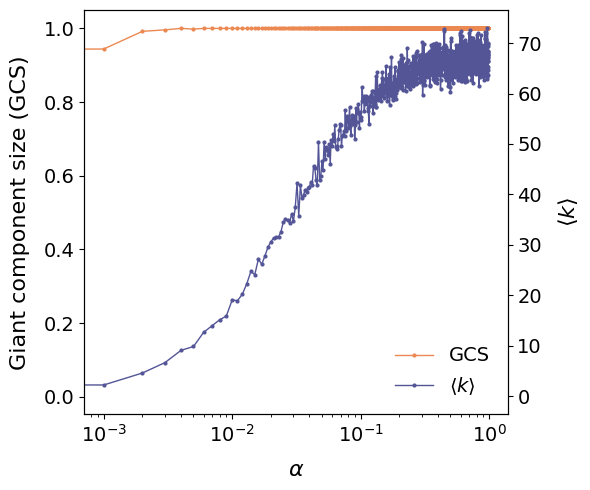

In [17]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(6,5))

# Eje izquierdo: GCS
ax1.plot(
    alpha, GCS,
    marker='o', markersize=2, linestyle='-',lw = 1,
    color=sunset2(0.8), label='GCS'
)
ax1.set_xlabel(r'$\alpha$', fontsize=16, labelpad=10)
ax1.set_ylabel('Giant component size (GCS)', fontsize=16, color='black', labelpad=10)
ax1.tick_params(axis='y', labelcolor='black')
ax1.set_xscale('log')
ax1.tick_params(axis='both', labelsize=14)

# Eje derecho: grado medio
ax2 = ax1.twinx()
ax2.plot(
    alpha, degrees,
    marker='o', markersize=2, linestyle='-', lw = 1,
    color=sunset2(0.2), label=r'$\langle k\rangle$'
)
ax2.set_ylabel(r'$\langle k\rangle$', fontsize=16, color='black', labelpad=10)
ax2.tick_params(axis='y', labelcolor='black')
ax2.tick_params(axis='both', labelsize=14)

# Opcional: leyenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=14, loc='lower right', frameon=False)

plt.tight_layout()
plt.show()


In [19]:
import os, numpy as np

path = "networks/adjacency_matrix_run011.bin"
size = os.path.getsize(path)
print("File size (bytes):", size)

with open(path, "rb") as f:
    N = np.fromfile(f, dtype=np.int32, count=1)[0]
    M = np.fromfile(f, dtype=np.int32, count=1)[0]
    alpha0 = np.fromfile(f, dtype=np.float64, count=1)[0]
    dalpha = np.fromfile(f, dtype=np.float64, count=1)[0]
    offset = f.tell()

print("N, M, alpha0, dalpha, offset:", N, M, alpha0, dalpha, offset)

expected = offset + int(M)*int(N)*int(N)  # uint8 => 1 byte por entrada
print("Expected size:", expected)
print("Matches:", expected == size)


File size (bytes): 249750024
N, M, alpha0, dalpha, offset: 500 1000 0.001 0.001 24
Expected size: 250000024
Matches: False


In [ ]:
import os
import numpy as np

import os, numpy as np, warnings

# Esta función carga un archivo binario que contiene matrices de adyacencia
# (probablemente guardadas como uint8, es decir, 0/1).
# Está diseñada para ser "segura": detecta archivos truncados,
# inconsistencias en el header, etc.
def load_run_bin_safe(path, allow_truncate=True):
    try:
        # obtiene el tamaño total del archivo en bytes
        size = os.path.getsize(path)

        # abrimos el archivo en modo binario para leer el header
        with open(path, "rb") as f:

            # N -> tamaño de la red (matriz NxN)
            N = np.fromfile(f, np.int32, 1)[0]

            # M_hdr -> número de matrices que el header dice que hay
            M_hdr = np.fromfile(f, np.int32, 1)[0]

            # alpha inicial
            alpha0 = np.fromfile(f, np.float64, 1)[0]

            # incremento de alpha entre matrices consecutivas
            dalpha = np.fromfile(f, np.float64, 1)[0]

            # posición actual del puntero → aquí empieza el bloque de matrices
            offset = f.tell()

        # cada matriz ocupa N*N bytes (uint8 = 1 byte)
        bytes_per_mat = int(N)*int(N)

        # tamaño real del bloque de datos
        payload = size - offset

        if payload <= 0:
            warnings.warn(f"{path}: fichero demasiado pequeño. Saltando.")
            return None

        # número REAL de matrices completas que caben en el archivo
        M_real = payload // bytes_per_mat

        # resto de bytes → si no es 0, el archivo está truncado
        rem = payload % bytes_per_mat

        if rem != 0:
            msg = f"{path}: TRUNCADO (M_completas={M_real}, resto={rem} bytes)."
            if allow_truncate:
                # seguimos adelante ignorando la parte corrupta
                warnings.warn(msg + " Recorto a matrices completas.")
            else:
                warnings.warn(msg + " Saltando fichero.")
                return None

        if M_real <= 0:
            warnings.warn(f"{path}: no contiene matrices completas. Saltando.")
            return None

        # si el header no coincide con lo que realmente hay en disco,
        # confiamos en el tamaño real
        if M_real != M_hdr:
            warnings.warn(f"{path}: M header={M_hdr}, M real={M_real}. Usando M real.")

        # memmap permite acceder al archivo SIN cargarlo entero en RAM
        # Esto es MUY importante si las redes son grandes.
        mats = np.memmap(path, dtype=np.uint8, mode="r", offset=offset, shape=(M_real, N, N))

        # reconstruimos el vector alpha:
        # alpha_i = alpha0 + i * dalpha
        alpha = alpha0 + dalpha*np.arange(M_real)

        return alpha, mats

    except Exception as e:
        # si cualquier cosa falla, no rompe el programa
        warnings.warn(f"{path}: error al leer ({e}). Saltando.")
        return None


In [59]:
import os, numpy as np

path = r"networks/adjacency_matrix_run016.bin"
size = os.path.getsize(path)

with open(path, "rb") as f:
    N = np.fromfile(f, np.int32, 1)[0]
    M_hdr = np.fromfile(f, np.int32, 1)[0]
    alpha0 = np.fromfile(f, np.float64, 1)[0]
    dalpha = np.fromfile(f, np.float64, 1)[0]
    offset = f.tell()

bytes_per_mat = N*N
payload = size - offset
M_real = payload // bytes_per_mat
rem = payload % bytes_per_mat

print("size:", size, "N:", N, "M_hdr:", M_hdr)
print("payload:", payload, "bytes_per_mat:", bytes_per_mat)
print("M_real:", M_real, "rem:", rem, "missing_to_full:", bytes_per_mat-rem if rem else 0)


size: 5246976 N: 500 M_hdr: 1000
payload: 5246952 bytes_per_mat: 250000
M_real: 20 rem: 246952 missing_to_full: 3048


In [27]:
import glob, os, re



# Esta función busca archivos que sigan un patrón concreto
# Por ejemplo: networks/adjacency_matrix_ng1_run0.bin, run1.bin, etc.
def select_runs(pattern="networks/adjacency_matrix_ng3_run*.bin", run_min=None, run_max=None):
    files = sorted(glob.glob(pattern))  # obtiene todos los archivos que coinciden con el patrón y los ordena
    out = []
    for f in files:
        # extrae el número de run del nombre del archivo usando regex
        m = re.search(r"run(\d+)", os.path.basename(f))
        if not m:
            continue  # si no encuentra "runX", ignora el archivo
        
        run = int(m.group(1))  # convierte el número encontrado a entero
        
        # filtros opcionales para quedarte solo con algunos runs
        if run_min is not None and run < run_min:
            continue
        if run_max is not None and run > run_max:
            continue
        
        out.append((run, f))  # guarda tupla (run_number, filepath)
    
    return out  # devuelve lista de (run, filepath)


import numpy as np

# Esta función calcula el grado medio de la red para cada alpha,
# promediando sobre múltiples runs
def mean_degree_over_runs(files):
    sum_k = None   # suma acumulada de grados medios
    sum_k2 = None  # suma acumulada de grados medios al cuadrado (para la std)
    n = 0          # contador de runs válidos
    alpha_ref = None  # guardará el vector alpha de referencia

    for file in files:
        # carga el archivo binario (asumiendo que load_run_bin_safe existe)
        out = load_run_bin_safe(file, allow_truncate=False)
        
        if out is None:
            print(f"Saltando {file}")
            continue
        
        alpha, mats = out  # alpha = parámetros, mats = matrices de adyacencia

        # array donde guardaremos el grado medio de cada alpha en ESTE run
        k_run = np.empty(len(alpha), dtype=np.float64)

        for i in range(len(alpha)):
            A = mats[i]  # matriz de adyacencia para el alpha i

            # grado de cada nodo:
            # sumamos cada fila -> número de conexiones salientes
            # restamos la diagonal para evitar autoconexiones
            deg = A.sum(axis=1).astype(np.int64) - np.diag(A).astype(np.int64)

            # guardamos el grado medio de la red
            k_run[i] = deg.mean()

        # inicialización en el primer run válido
        if alpha_ref is None:
            alpha_ref = alpha
            sum_k = np.zeros_like(k_run)
            sum_k2 = np.zeros_like(k_run)

        # si distintos runs tienen distinta longitud (ej 999 vs 1000)
        # recortamos al mínimo común para evitar errores
        m = min(len(alpha_ref), len(k_run))
        sum_k[:m] += k_run[:m]
        sum_k2[:m] += k_run[:m]**2
        n += 1

    # media final
    k_mean = sum_k / n

    # desviación estándar usando:
    # std = sqrt(<k²> - <k>²)
    k_std = np.sqrt(np.maximum(sum_k2 / n - k_mean**2, 0.0))

    return alpha_ref[:len(k_mean)], k_mean, k_std, n


import matplotlib.pyplot as plt

run_min = 0
run_max = 20  # hasta qué run quieres incluir

# selecciona los runs dentro de ese rango
runs = select_runs(run_min=run_min, run_max=run_max)

# se queda solo con las rutas de archivo
files = [f for _, f in runs]

print("Usando runs:", [r for r,_ in runs])

# calcula grado medio y desviación típica
alpha, k_mean, k_std, n_runs = mean_degree_over_runs(files)

# guarda resultados en un txt:
# columnas -> alpha | mean_degree | std_degree
savedata_file = "mean_degree_over_runs_agg3.txt"

np.savetxt(
    savedata_file,
    np.column_stack((alpha, k_mean, k_std)),
    header="alpha\tmean_degree\tstd_degree"
)


Usando runs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]


C:\Users\Admin\AppData\Local\Temp\ipykernel_18944\3462246792.py:38: UserWarning: networks\adjacency_matrix_ng3_run000.bin: M header=1000, M real=999. Usando M real.
  warnings.warn(f"{path}: M header={M_hdr}, M real={M_real}. Usando M real.")
C:\Users\Admin\AppData\Local\Temp\ipykernel_18944\3462246792.py:38: UserWarning: networks\adjacency_matrix_ng3_run001.bin: M header=1000, M real=999. Usando M real.
  warnings.warn(f"{path}: M header={M_hdr}, M real={M_real}. Usando M real.")
C:\Users\Admin\AppData\Local\Temp\ipykernel_18944\3462246792.py:38: UserWarning: networks\adjacency_matrix_ng3_run002.bin: M header=1000, M real=999. Usando M real.
  warnings.warn(f"{path}: M header={M_hdr}, M real={M_real}. Usando M real.")
C:\Users\Admin\AppData\Local\Temp\ipykernel_18944\3462246792.py:38: UserWarning: networks\adjacency_matrix_ng3_run003.bin: M header=1000, M real=999. Usando M real.
  warnings.warn(f"{path}: M header={M_hdr}, M real={M_real}. Usando M real.")
C:\Users\Admin\AppData\Local

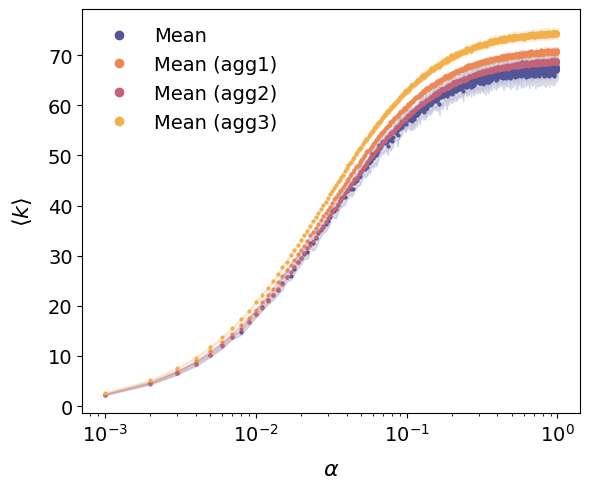

In [28]:
data_random = np.loadtxt("mean_degree_over_runs.txt")
data_agg1 = np.loadtxt("mean_degree_over_runs_agg1.txt")
data_agg2 = np.loadtxt("mean_degree_over_runs_agg2.txt")
data_agg3 = np.loadtxt("mean_degree_over_runs_agg3.txt")

alpha_random = data_random[:,0]
mean_degree_random = data_random[:,1]
std_degree_random = data_random[:,2]

alpha_agg1 = data_agg1[:,0]
mean_degree_agg1 = data_agg1[:,1]
std_degree_agg1 = data_agg1[:,2]

alpha_agg2 = data_agg2[:,0]
mean_degree_agg2 = data_agg2[:,1]
std_degree_agg2 = data_agg2[:,2]

alpha_agg3 = data_agg3[:,0]
mean_degree_agg3 = data_agg3[:,1]
std_degree_agg3 = data_agg3[:,2]


plt.figure(figsize=(6,5))
plt.plot(alpha_random, mean_degree_random, marker='o', markersize=2, linestyle='-', lw=0, color=sunset2(0.2),label="Mean")
plt.fill_between(alpha_random, mean_degree_random-std_degree_random, mean_degree_random+std_degree_random, alpha=0.2, color=sunset2(0.2))

plt.plot(alpha_agg1, mean_degree_agg1, marker='o', markersize=2, linestyle='-', lw=0, color=sunset2(0.8), label="Mean (agg1)")
plt.fill_between(alpha_agg1, mean_degree_agg1-std_degree_agg1, mean_degree_agg1+std_degree_agg1, alpha=0.2, color=sunset2(0.5))

plt.plot(alpha_agg2, mean_degree_agg2, marker='o', markersize=2, linestyle='-', lw=0, color=sunset2(0.5), label="Mean (agg2)")
plt.fill_between(alpha_agg2, mean_degree_agg2-std_degree_agg2, mean_degree_agg2+std_degree_agg2, alpha=0.2, color=sunset2(0.8))

plt.plot(alpha_agg3, mean_degree_agg3, marker='o', markersize=2, linestyle='-', lw=0, color=sunset2(1.0), label="Mean (agg3)")
plt.fill_between(alpha_agg3, mean_degree_agg3-std_degree_agg3, mean_degree_agg3+std_degree_agg3, alpha=0.2, color=sunset2(1.0))



plt.xlabel(r'$\alpha$', fontsize=16, labelpad=10)
plt.ylabel(r'$\langle k\rangle$', fontsize=16, labelpad=10)
plt.xscale('log')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.legend(loc = 'best', frameon = False, fontsize = 14, markerscale = 3)
plt.show()

# Tune aggregation

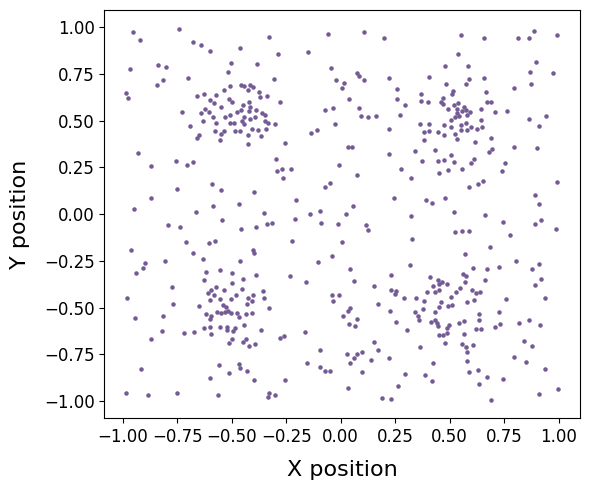

In [18]:
positions = np.loadtxt("agrupation/neurons_params_agg1_ng4_nic50_m0.50_s0.10.txt", skiprows=1)
x = positions[:,0]
y = positions[:,1]

plt.figure(figsize=(6,5))
plt.scatter(x, y, s=5, color=sunset2(0.3))
plt.xlabel('X position', fontsize=16, labelpad=10)
plt.ylabel('Y position', fontsize=16, labelpad=10)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()

plt.show()

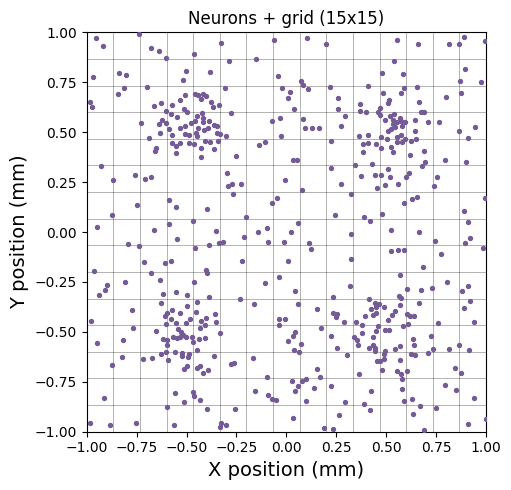

In [19]:
import numpy as np
import matplotlib.pyplot as plt

def plot_positions_with_grid(x, y, L=2.0, ngrid=25, box_centered=True,
                             show_heatmap=False, s=8):
    # límites de la caja
    if box_centered:
        xmin, xmax = -L/2, L/2
        ymin, ymax = -L/2, L/2
    else:
        xmin, xmax = 0.0, L
        ymin, ymax = 0.0, L

    # edges del grid (exactamente los bins)
    xedges = np.linspace(xmin, xmax, ngrid+1)
    yedges = np.linspace(ymin, ymax, ngrid+1)

    fig, ax = plt.subplots(figsize=(6,5))

    # (opcional) heatmap de conteos
    if show_heatmap:
        H, _, _ = np.histogram2d(x, y, bins=ngrid, range=[[xmin,xmax],[ymin,ymax]])
        # imshow espera matriz [y,x], por eso el .T
        ax.imshow(
            H.T,
            origin="lower",
            extent=[xmin, xmax, ymin, ymax],
            aspect="equal",
            alpha=0.35
        )

    # puntos de neuronas
    ax.scatter(x, y, s=s, color=sunset2(0.3), zorder=3)

    # dibujar líneas verticales y horizontales del grid
    for xe in xedges:
        ax.plot([xe, xe], [ymin, ymax], lw=0.6, alpha=0.35, color="k", zorder=2)
    for ye in yedges:
        ax.plot([xmin, xmax], [ye, ye], lw=0.6, alpha=0.35, color="k", zorder=2)

    # límites y labels
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("X position (mm)", fontsize=14)
    ax.set_ylabel("Y position (mm)", fontsize=14)
    ax.set_title(f"Neurons + grid ({ngrid}x{ngrid})", fontsize=12)
    plt.tight_layout()
    plt.show()


# --- Uso con tus datos ---
positions = np.loadtxt("agrupation/neurons_params_agg1_ng4_nic50_m0.50_s0.10.txt", skiprows=1)
x = positions[:,0]
y = positions[:,1]

plot_positions_with_grid(x, y, L=2.0, ngrid=15, box_centered=True, show_heatmap=False)
# o con heatmap:
# plot_positions_with_grid(x, y, L=2.0, ngrid=25, box_centered=True, show_heatmap=True)


Gini (ngrid=15): 0.4921


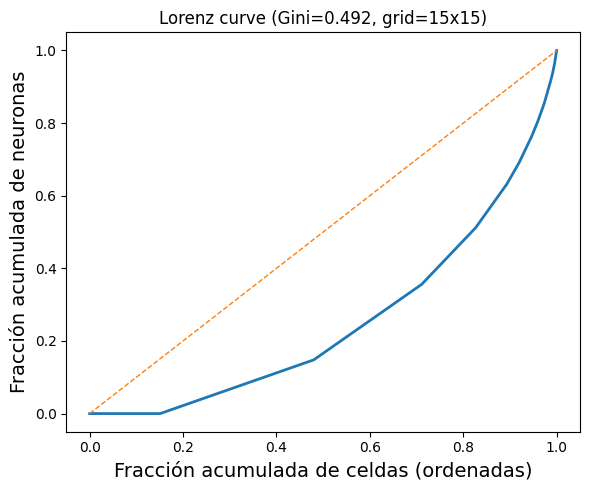

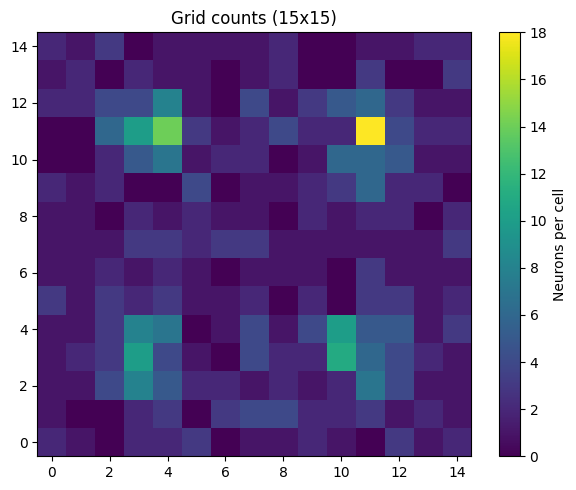

In [24]:
import numpy as np
import matplotlib.pyplot as plt

def gini_from_counts(counts: np.ndarray) -> float:
    """
    Gini para un array 1D no negativo.
    Incluye celdas con 0 (lo normal en clustering).
    """
    x = counts.astype(np.float64)
    if np.any(x < 0):
        raise ValueError("counts debe ser no negativo")
    s = x.sum()
    if s == 0:
        return 0.0

    x_sorted = np.sort(x)
    n = x_sorted.size
    # fórmula eficiente con datos ordenados
    i = np.arange(1, n+1)
    G = (2.0*np.sum(i * x_sorted) / (n * s)) - (n + 1.0)/n
    return G

def grid_counts(x, y, L=2.0, ngrid=20, box_centered=True):
    """
    Devuelve:
    - counts_flat: conteos por celda (aplanado, incluye ceros)
    - counts_grid: matriz (ngrid, ngrid)
    - edges: edges usados (para debug)
    """
    if box_centered:
        xmin, xmax = -L/2, L/2
        ymin, ymax = -L/2, L/2
    else:
        xmin, xmax = 0.0, L
        ymin, ymax = 0.0, L

    # histogram2d: H[i,j] cuenta puntos en bin x_i, y_j
    H, xedges, yedges = np.histogram2d(
        x, y,
        bins=ngrid,
        range=[[xmin, xmax], [ymin, ymax]]
    )

    counts_grid = H.astype(int)
    counts_flat = counts_grid.ravel()  # incluye ceros
    return counts_flat, counts_grid, (xedges, yedges)

def lorenz_curve_from_counts(counts_flat):
    """
    Devuelve:
    - p: fracción acumulada de celdas (0..1)
    - Lp: fracción acumulada de neuronas (0..1)
    - counts_sorted: conteos ordenados
    """
    counts_sorted = np.sort(counts_flat)
    cum = np.cumsum(counts_sorted).astype(np.float64)
    total = cum[-1] if cum.size else 0.0
    if total == 0:
        # caso degenerado
        p = np.linspace(0, 1, len(counts_sorted)+1)
        Lp = np.zeros_like(p)
        return p, Lp, counts_sorted

    Lp = np.concatenate([[0.0], cum / total])  # empieza en 0
    p  = np.linspace(0, 1, len(counts_sorted)+1)
    return p, Lp, counts_sorted

# --- TU CÓDIGO DE LECTURA ---
positions = np.loadtxt("agrupation/neurons_params_agg1_ng4_nic50_m0.50_s0.10.txt", skiprows=1)
x = positions[:, 0]
y = positions[:, 1]

# --- ELIGE RESOLUCIÓN DEL GRID ---
L = 2.0
ngrid = 15  # <-- cámbialo: 10, 20, 30, 50...

counts_flat, counts_grid, edges = grid_counts(x, y, L=L, ngrid=ngrid, box_centered=True)

# Lorenz curve (tu “array ordenado + suma acumulada normalizada”)
p, Lp, counts_sorted = lorenz_curve_from_counts(counts_flat)

# Gini
G = gini_from_counts(counts_flat)
print(f"Gini (ngrid={ngrid}): {G:.4f}")

# --- PLOTS ---
plt.figure(figsize=(6,5))
plt.plot(p, Lp, lw=2)
plt.plot([0,1], [0,1], linestyle="--", lw=1)  # línea de igualdad
plt.xlabel("Fracción acumulada de celdas (ordenadas)", fontsize=14)
plt.ylabel("Fracción acumulada de neuronas", fontsize=14)
plt.title(f"Lorenz curve (Gini={G:.3f}, grid={ngrid}x{ngrid})", fontsize=12)
plt.tight_layout()
plt.show()

# (Opcional) mapa de calor de conteos en la cuadrícula
plt.figure(figsize=(6,5))
plt.imshow(counts_grid.T, origin="lower", aspect="auto")
plt.colorbar(label="Neurons per cell")
plt.title(f"Grid counts ({ngrid}x{ngrid})", fontsize=12)
plt.tight_layout()
plt.show()
